# <span style="color:orange;font-weight:bold">Assignment 1.1 - Responsible AI Evaluation</span>

### **INFO3022 Advanced Topics in Data Analytics**

**Student:** Michael Hudson

**Dataset:** UCI Credit Card Default Dataset

**Date:** July 2026

---

### **Declaration**

<table>
<tr>
<td style="width:150px">
    <img src="https://raw.githubusercontent.com/michaelhudson2205/INFO3022_Practicals/main/Mike_Matrix.png" alt="Mike Matrix" width="150"/>
</td>
<td>
    I declare that the work hereby submitted is my own original work. AI tools were used to assist with task interpretation, code explanations and debugging. All code, analysis and conclusions were completed by me. Python code was developed in a Jupyter Notebook using VS Code as the IDE. Git was used for version control and working docs were synced on GitHub in a <span style="color:orange; font-weight:bold">private</span> repository.
</td>
</tr>
</table>

### <span style="color:orange;font-weight:bold">1. Introduction</span>

### <span style="color:orange;font-weight:bold">2. Setup</span>

This section imports the Python libraries required for the analysis and loads the UCI Credit Card Default dataset into a pandas DataFrame.

**2.1 Import libraries**

In [107]:
# =================================================
# Import required libraries
# =================================================

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.cm as cm

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from fairlearn.metrics import (
    MetricFrame,
    selection_rate,
    demographic_parity_difference,
    equalized_odds_difference
)

from fairlearn.reductions import ExponentiatedGradient, DemographicParity, EqualizedOdds

from fairlearn.postprocessing import ThresholdOptimizer

**2.2 Load dataset**

In [60]:
# =================================================
# Load the dataset
# =================================================

df = pd.read_csv("UCI_Credit_Card.csv")

### <span style="color:orange;font-weight:bold">3. Dataset Overview</span>

This section explores the structure and characteristics of the UCI Credit Card Default dataset. The aim is to understand the variables available, identify the prediction target, and examine the quality and composition of the data before building a baseline classification model.

In [61]:
# =================================================
# Dataset dimensions
# =================================================

print(f"Number of records: {df.shape[0]}")
print(f"Number of features: {df.shape[1]}")

Number of records: 30000
Number of features: 25


In [62]:
# =================================================
# Preview the dataset
# =================================================

df.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,1,20000.0,2,2,1,24,2,2,-1,-1,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,2,2,2,26,-1,2,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,2,2,2,34,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,2,2,1,37,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,1,2,1,57,-1,0,-1,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


In [63]:
# =================================================
# Data types and completeness
# =================================================

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ID                          30000 non-null  int64  
 1   LIMIT_BAL                   30000 non-null  float64
 2   SEX                         30000 non-null  int64  
 3   EDUCATION                   30000 non-null  int64  
 4   MARRIAGE                    30000 non-null  int64  
 5   AGE                         30000 non-null  int64  
 6   PAY_0                       30000 non-null  int64  
 7   PAY_2                       30000 non-null  int64  
 8   PAY_3                       30000 non-null  int64  
 9   PAY_4                       30000 non-null  int64  
 10  PAY_5                       30000 non-null  int64  
 11  PAY_6                       30000 non-null  int64  
 12  BILL_AMT1                   30000 non-null  float64
 13  BILL_AMT2                   30000 non-null

In [64]:
# =================================================
# Variable types
# =================================================

print(df.dtypes)

ID                              int64
LIMIT_BAL                     float64
SEX                             int64
EDUCATION                       int64
MARRIAGE                        int64
AGE                             int64
PAY_0                           int64
PAY_2                           int64
PAY_3                           int64
PAY_4                           int64
PAY_5                           int64
PAY_6                           int64
BILL_AMT1                     float64
BILL_AMT2                     float64
BILL_AMT3                     float64
BILL_AMT4                     float64
BILL_AMT5                     float64
BILL_AMT6                     float64
PAY_AMT1                      float64
PAY_AMT2                      float64
PAY_AMT3                      float64
PAY_AMT4                      float64
PAY_AMT5                      float64
PAY_AMT6                      float64
default.payment.next.month      int64
dtype: object


The dataset contains a mixture of demographic, financial and repayment history variables. Although all variables are stored as numeric values, several represent categorical information encoded as integers (for example, sex, education and marital status), while others are continuous numerical measurements such as credit limit, bill amounts and payment amounts. This distinction is important because categorical and numerical variables require different preprocessing before model training.

In [65]:
# =================================================
# Summary statistics
# =================================================

df.describe(include='all')

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,...,30000.000000,30000.000000,30000.000000,30000.000000,3.000000e+04,30000.00000,30000.000000,30000.000000,30000.000000,30000.000000
mean,15000.500000,167484.322667,1.603733,1.853133,1.551867,35.485500,-0.016700,-0.133767,-0.166200,-0.220667,...,43262.948967,40311.400967,38871.760400,5663.580500,5.921163e+03,5225.68150,4826.076867,4799.387633,5215.502567,0.221200
std,8660.398374,129747.661567,0.489129,0.790349,0.521970,9.217904,1.123802,1.197186,1.196868,1.169139,...,64332.856134,60797.155770,59554.107537,16563.280354,2.304087e+04,17606.96147,15666.159744,15278.305679,17777.465775,0.415062
min,1.000000,10000.000000,1.000000,0.000000,0.000000,21.000000,-2.000000,-2.000000,-2.000000,-2.000000,...,-170000.000000,-81334.000000,-339603.000000,0.000000,0.000000e+00,0.00000,0.000000,0.000000,0.000000,0.000000
25%,7500.750000,50000.000000,1.000000,1.000000,1.000000,28.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,2326.750000,1763.000000,1256.000000,1000.000000,8.330000e+02,390.00000,296.000000,252.500000,117.750000,0.000000
50%,15000.500000,140000.000000,2.000000,2.000000,2.000000,34.000000,0.000000,0.000000,0.000000,0.000000,...,19052.000000,18104.500000,17071.000000,2100.000000,2.009000e+03,1800.00000,1500.000000,1500.000000,1500.000000,0.000000
75%,22500.250000,240000.000000,2.000000,2.000000,2.000000,41.000000,0.000000,0.000000,0.000000,0.000000,...,54506.000000,50190.500000,49198.250000,5006.000000,5.000000e+03,4505.00000,4013.250000,4031.500000,4000.000000,0.000000
max,30000.000000,1000000.000000,2.000000,6.000000,3.000000,79.000000,8.000000,8.000000,8.000000,8.000000,...,891586.000000,927171.000000,961664.000000,873552.000000,1.684259e+06,896040.00000,621000.000000,426529.000000,528666.000000,1.000000


The summary statistics indicate considerable variation in financial variables such as credit limit, bill amounts and payment amounts, reflecting the diverse financial circumstances of customers represented in the dataset. These differences are expected in real-world lending data and motivate the use of feature scaling during model development.

In [66]:
# =================================================
# Missing values
# =================================================

missing = df.isnull().sum()
missing[missing > 0]

Series([], dtype: int64)

No missing values were identified in the dataset. Consequently, no imputation was required. However, the absence of missing values does not necessarily imply that the data are free from quality issues, as encoded categories and historical biases may still influence model behaviour.

In [67]:
# =================================================
# Target variable
# =================================================

target = 'default.payment.next.month'

print(df[target].value_counts())
print(df[target].value_counts(normalize=True) * 100)

default.payment.next.month
0    23364
1     6636
Name: count, dtype: int64
default.payment.next.month
0    77.88
1    22.12
Name: proportion, dtype: float64


In [68]:
# =================================================
# Variable types
# =================================================

categorical_cols = [
    'SEX',
    'EDUCATION',
    'MARRIAGE'
]

numerical_cols = [
    col for col in df.columns if col not in categorical_cols + [target]
]

print(f"Categorical columns: {categorical_cols}")
print(f"Number of categorical columns: {len(categorical_cols)}")
print(f"Numerical columns: {numerical_cols}")
print(f"Number of numerical columns: {len(numerical_cols)}")

Categorical columns: ['SEX', 'EDUCATION', 'MARRIAGE']
Number of categorical columns: 3
Numerical columns: ['ID', 'LIMIT_BAL', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']
Number of numerical columns: 21


The dataset contains **30,000 customer records** and **25 variables**, with each record representing an individual credit card customer. The variables include demographic characteristics (such as sex, education and marital status), financial information (credit limit, bill amounts and payment amounts), and repayment history over the previous six months. The prediction target is **`default.payment.next.month`**, indicating whether the customer defaulted on their next payment. No data cleaning was performed, consistent with the assignment instructions, although any limitations identified are discussed later as potential Responsible AI risks.

**Distribution of the Target Variable**

The target variable (`default.payment.next.month`) records whether a customer defaulted on their next credit card payment. Examining its distribution provides an indication of whether the dataset is balanced before model development.

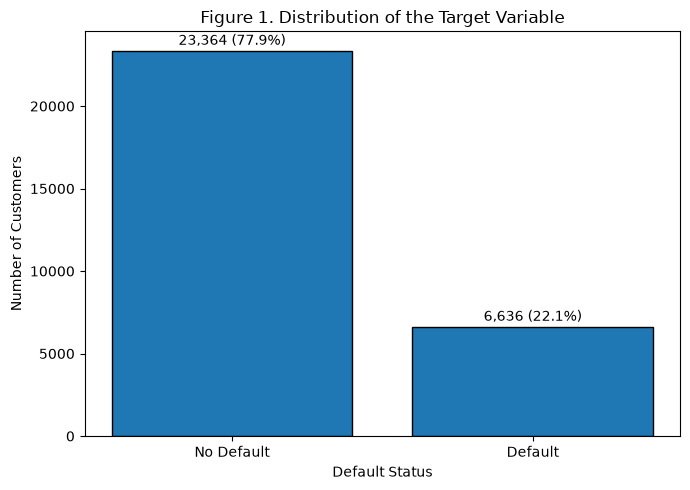

In [69]:
# =================================================
# Distribution of the target variable
# =================================================

# Count the number of observations in each class
target_counts = df[target].value_counts().sort_index()

# Calculate percentages
target_percentages = target_counts / target_counts.sum() * 100

# Create labels for the classes
labels = ["No Default", "Default"]

# Create the figure
plt.figure(figsize=(7, 5))

bars = plt.bar(labels, target_counts, edgecolor="black")

# Add the count and percentage above each bar
for i, bar in enumerate(bars):
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 150,
        f"{target_counts.iloc[i]:,} ({target_percentages.iloc[i]:.1f}%)",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.title("Figure 1. Distribution of the Target Variable")
plt.xlabel("Default Status")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

**Figure 1. Distribution of the target variable**

Figure 1 shows that the dataset contains substantially more customers who did **not** default than customers who **did** default on their next payment. This indicates that the prediction task is moderately imbalanced, an important consideration when evaluating model performance because overall accuracy alone may not adequately reflect performance on the minority class. This class distribution will also be considered when interpreting the fairness metrics in later sections.

In [70]:
# =================================================
# Key variables used in this study
# =================================================

key_variables = pd.DataFrame({
    "Variable": [
        "SEX",
        "AGE",
        "EDUCATION",
        "MARRIAGE",
        "default.payment.next.month"
    ],
    "Purpose": [
        "Protected attribute for fairness analysis",
        "Demographic characteristic",
        "Socio-economic characteristics",
        "Demographic characteristic",
        "Prediction target"
    ]
})

key_variables

,Variable,Purpose
0,SEX,Protected attribute for fairness analysis
1,AGE,Demographic characteristic
2,EDUCATION,Socio-economic characteristics
3,MARRIAGE,Demographic characteristic
4,default.payment.next.month,Prediction target


In [71]:
# =================================================
# Define key variables used throughout the notebook
# =================================================

TARGET = "default.payment.next.month"
PROTECTED_ATTRIBUTE = "SEX"
FEATURES = df.drop(columns=[TARGET])
LABEL = df[TARGET]

SEX_LABELS = {
    1: "Male",
    2: "Female"
}

### <span style="color:orange;font-weight:bold">4. What the Outcome Measures</span>

The purpose of this section is to examine what the prediction target actually measures and whether it is an appropriate representation of the concept the lender wishes to predict. In Responsible AI, it is important to distinguish between the recorded outcome in the dataset and the real-world construct that the automated decision system is intended to support.

The target variable in this dataset is **`default.payment.next.month`**, which records whether a customer defaulted on their next scheduled credit card payment. Although this outcome is observable and measurable, it is only an indirect indicator of the concept that the lender actually wishes to predict. The underlying construct of interest is **creditworthiness** - the likelihood that an applicant will be able and willing to repay future debt responsibly. Creditworthiness cannot be observed directly, so the dataset uses next-month payment default as a proxy measure. Using default as a proxy assumes that customers who default are poor credit risks and customers who do not default are good credit risks. While this assumption is often reasonable, it does not always hold. A customer may miss a payment because of a temporary illness, job loss or unexpected financial hardship despite normally being financially responsible. Conversely, another customer may avoid default in the short term by borrowing elsewhere or making only minimum repayments while remaining at high long-term risk. As a result, the prediction target does not perfectly capture the construct of creditworthiness. Any model trained on this dataset will therefore learn to predict historical payment default rather than the broader concept of an applicant's future financial reliability. This limitation should be recognised when interpreting model predictions and making lending decisions.

**Potential harms arising from the outcome definition**

If the proxy measure does not accurately represent creditworthiness, incorrect lending decisions may occur. A false positive may incorrectly identify a financially responsible applicant as likely to default, resulting in an unfair denial of credit. Conversely, a false negative may approve credit for an applicant who subsequently defaults, exposing the lender to financial loss. These risks arise from the gap between the measured outcome and the broader construct that the decision system is intended to support.

In this dataset, the outcome records only whether a payment default occurred in the following month. It does not capture the reason for the default, whether the default was temporary or persistent, or whether the customer later recovered financially. Consequently, important contextual information that could influence a customer's true creditworthiness is absent from the data. This limitation means that the model's predictions should support, rather than replace, human decision-making in credit assessment.

### <span style="color:orange;font-weight:bold">5. Subgroup Representation</span>

This section examines how key demographic groups are represented within the dataset. Understanding subgroup representation is important because uneven coverage can influence both model performance and fairness. The analysis focuses on sex, age and education because these characteristics are relevant to fairness, reliability and responsible lending decisions.

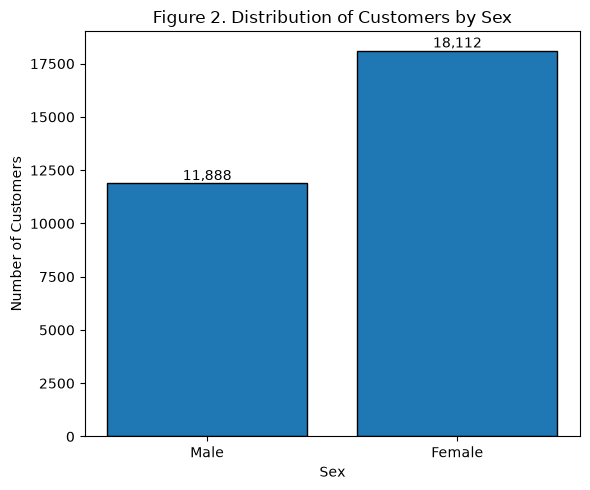

In [72]:
# =================================================
# Distribution by sex
# =================================================

sex_counts = df["SEX"].value_counts().sort_index()

labels = ["Male", "Female"]

plt.figure(figsize=(6,5))

bars = plt.bar(labels, sex_counts, edgecolor="black")

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 150,
        f"{height:,}",
        ha="center"
    )

plt.title("Figure 2. Distribution of Customers by Sex")
plt.xlabel("Sex")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

Figure 2 shows that both males and females are well represented in the dataset. Although the distribution is not perfectly balanced, neither group is sparsely represented, providing sufficient observations for meaningful fairness evaluation.

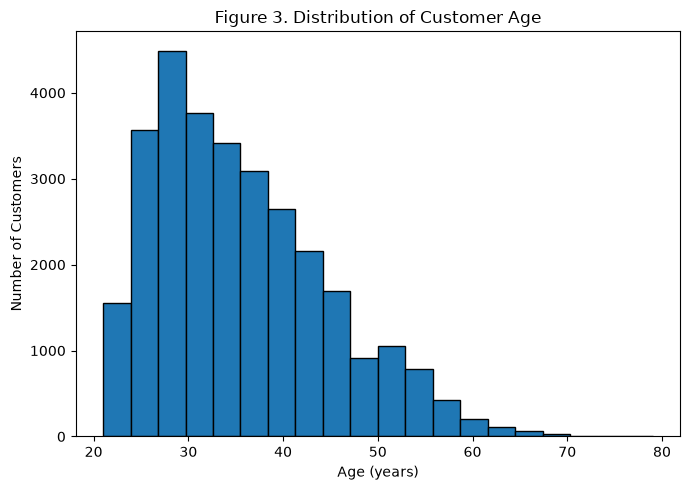

In [73]:
# =================================================
# Age Distribution
# =================================================

plt.figure(figsize=(7,5))

plt.hist(df["AGE"], bins=20, edgecolor="black")

plt.title("Figure 3. Distribution of Customer Age")
plt.xlabel("Age (years)")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

Figure 3 shows that customer ages range from 21 to 79 years, with a mean age of approximately 35.5 years. Most customers are concentrated between 28 and 41 years of age, indicating that the dataset is dominated by younger and middle-aged adults. The distribution is slightly positively skewed, with relatively few customers in the older age groups. While the dataset provides broad age coverage, the relatively small number of older customers means that performance estimates for these age groups may be less reliable, highlighting the importance of evaluating model performance separately across demographic groups. As age is an important demographic characteristic in lending decisions, model performance should later be assessed to ensure that prediction quality and fairness are consistent across different age groups.

In [74]:
df["AGE"].describe()

count    30000.000000
mean        35.485500
std          9.217904
min         21.000000
25%         28.000000
50%         34.000000
75%         41.000000
max         79.000000
Name: AGE, dtype: float64

In [75]:
df["AGE"].value_counts().sort_index().head()

AGE
21      67
22     560
23     931
24    1127
25    1186
Name: count, dtype: int64

In [76]:
df["AGE"].value_counts().sort_index().tail()

AGE
72    3
73    4
74    1
75    3
79    1
Name: count, dtype: int64

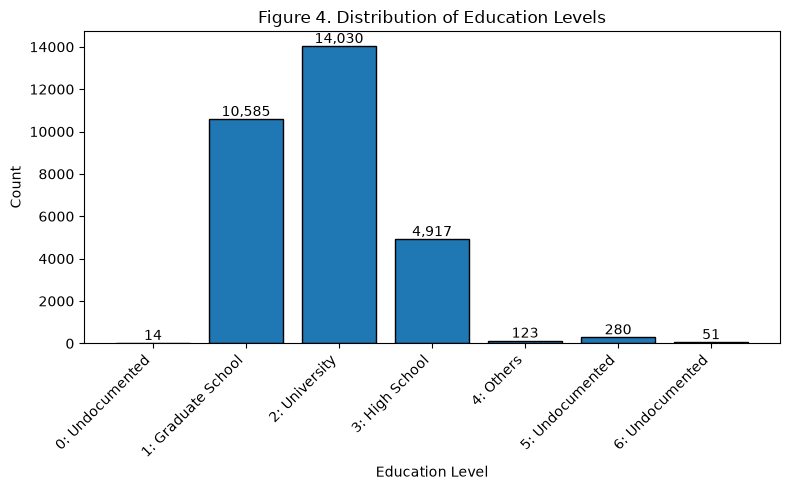

In [77]:
# =================================================
# Distribution of Education Levels
# =================================================

education_counts = df["EDUCATION"].value_counts().sort_index()

education_labels = [
    "0: Undocumented",
    "1: Graduate School",
    "2: University",
    "3: High School",
    "4: Others",
    "5: Undocumented",
    "6: Undocumented"
]

plt.figure(figsize=(8,5))

bars = plt.bar(education_labels, education_counts, edgecolor="black")

for i, bar in enumerate(bars):
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 150,
        f"{height:,}",
        ha="center"
    )

plt.title("Figure 4. Distribution of Education Levels")
plt.xlabel("Education Level")
plt.ylabel("Count")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

Figure 4 shows that the dataset is dominated by customers with higher levels of formal education. University graduates represent the largest group (46.8%), followed by graduate school qualifications (35.3%), while customers with a high school education account for 16.4% of the dataset. Together, these three documented education categories represent more than 98% of all customer records, indicating that the dataset provides strong coverage of these educational groups.

A small proportion of records (approximately 1.6%) are assigned to education codes 0, 4, 5 and 6. While code 4 is defined as "Other", codes 0, 5 and 6 are not documented in the original UCI dataset description. Although these undocumented categories represent only a small fraction of the data, they introduce ambiguity into the dataset and should be recognised as a potential data quality risk. Such inconsistencies highlight the importance of validating categorical variables before deploying automated decision-making systems in lending applications.

In [78]:
education_counts = df["EDUCATION"].value_counts().sort_index()
education_counts

EDUCATION
0       14
1    10585
2    14030
3     4917
4      123
5      280
6       51
Name: count, dtype: int64

In [79]:
df["EDUCATION"].value_counts(normalize=True).sort_index() * 100

EDUCATION
0     0.046667
1    35.283333
2    46.766667
3    16.390000
4     0.410000
5     0.933333
6     0.170000
Name: proportion, dtype: float64

### <span style="color:orange;font-weight:bold">6. Baseline Model and Fairness Analysis</span>

#### **6.1 Data Preparation**

Before training the baseline model, the dataset was prepared by separating the prediction target from the explanatory variables. The target variable (`default.payment.next.month`) represents whether a customer defaulted on their next credit card payment. All remaining variables were used as explanatory features for the baseline classifier. The protected attribute (`SEX`) was retained separately so that model performance and fairness could later be evaluated across demographic groups.

The dataset was then divided into training and testing sets using a stratified split. Stratification preserves the proportion of customers who defaulted in both datasets, ensuring that the training and evaluation data remain representative of the original class distribution.

In [80]:
# =================================================
# Configuration
# =================================================

TARGET_COLUMN = "default.payment.next.month"
PROTECTED_ATTRIBUTE = "SEX"

TEST_SIZE = 0.25
RANDOM_STATE = 42

In [81]:
# =================================================
# Define Features, Target and Protected Attribute
# =================================================

X = df.drop(columns=[TARGET_COLUMN])
y = df[TARGET_COLUMN]

A = df[PROTECTED_ATTRIBUTE]

print(f"Number of observations: {len(df):,}")
print(f"Number of features    : {X.shape[1]}")
print(f"Target variable       : {TARGET_COLUMN}")
print(f"Protected attribute   : {PROTECTED_ATTRIBUTE}")

Number of observations: 30,000
Number of features    : 24
Target variable       : default.payment.next.month
Protected attribute   : SEX


In [82]:
# =================================================
# Train/test split
# =================================================

X_train, X_test, y_train, y_test, A_train, A_test = train_test_split(
    X, y, A, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)

print(f"Training set size: {len(X_train):,}")
print(f"Test set size    : {len(X_test):,}")

Training set size: 22,500
Test set size    : 7,500


In [83]:
# =================================================
# Verify Class Distribution in Train and Test Sets
# =================================================

print("Original Dataset")
print(y.value_counts(normalize=True).rename("Proportion"))

print("\nTraining Dataset")
print(y_train.value_counts(normalize=True).rename("Proportion"))

print("\nTest Dataset")
print(y_test.value_counts(normalize=True).rename("Proportion"))

Original Dataset
default.payment.next.month
0    0.7788
1    0.2212
Name: Proportion, dtype: float64

Training Dataset
default.payment.next.month
0    0.7788
1    0.2212
Name: Proportion, dtype: float64

Test Dataset
default.payment.next.month
0    0.7788
1    0.2212
Name: Proportion, dtype: float64


#### **6.2 Build the Baseline Model**

A Logistic Regression classifier was selected as the baseline model. Logistic Regression is widely used for binary classification problems and provides an appropriate baseline because it is simple, interpretable and computationally efficient. The purpose of the baseline model is not to maximise predictive accuracy, but to provide a reference point against which fairness metrics and mitigation strategies can later be compared.

Prior to model training, all numerical variables were standardised using `StandardScaler`. Standardisation ensures that variables measured on different scales contribute more consistently to the optimisation process used by Logistic Regression.

In [84]:
# =================================================
# Build the Baseline Logistic Regression Model
# =================================================

baseline_model = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
])

baseline_model.fit(X_train, y_train)

print("Baseline model trained successfully.")

Baseline model trained successfully.


In [85]:
# =================================================
# Generate Predictions
# =================================================

y_pred = baseline_model.predict(X_test)

print("Predictions generated successfully.")

Predictions generated successfully.


#### **6.3 Evaluate the Baseline Model**

The baseline Logistic Regression model was evaluated using a separate testing dataset. Overall model performance was assessed using classification accuracy, a confusion matrix and a classification report. These metrics provide a benchmark against which subgroup performance and fairness metrics can later be compared.

In [86]:
# =================================================
# Overall Model Accuracy
# =================================================

accuracy = accuracy_score(y_test, y_pred)

print(f"Baseline Accuracy: {accuracy:.4f} ({accuracy:.2%})")

Baseline Accuracy: 0.8097 (80.97%)


In [87]:
# =================================================
# Confusion Matrix
# =================================================

cm = confusion_matrix(y_test, y_pred)

cm_df = pd.DataFrame(cm, index=["Actual No Default", "Actual Default"], columns=["Predicted No Default", "Predicted Default"])
print("Confusion Matrix:")
print(cm_df)

Confusion Matrix:
                   Predicted No Default  Predicted Default
Actual No Default                  5673                168
Actual Default                     1259                400


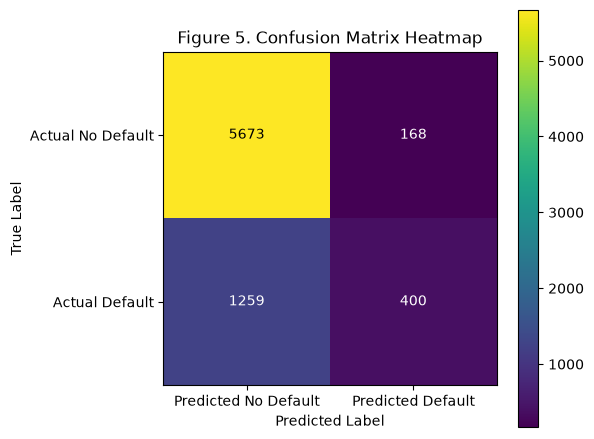

In [88]:
# =================================================
# Confusion Matrix Heatmap
# =================================================

plt.figure(figsize=(6, 5))

plt.imshow(cm, interpolation='nearest')

plt.colorbar()

plt.xticks(ticks=[0, 1], labels=["Predicted No Default", "Predicted Default"])
plt.yticks(ticks=[0, 1], labels=["Actual No Default", "Actual Default"])

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center", color="black" if cm[i, j] > cm.max()/2 else "white")

plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.title("Figure 5. Confusion Matrix Heatmap")

plt.tight_layout()
plt.show()

In [89]:
# =================================================
# Extract Confusion Matrix Components
# =================================================

tn, fp, fn, tp = cm.ravel()

print(f"True Negatives (TN) : {tn}")
print(f"False Positives (FP): {fp}")
print(f"False Negatives (FN): {fn}")
print(f"True Positives (TP) : {tp}")

True Negatives (TN) : 5673
False Positives (FP): 168
False Negatives (FN): 1259
True Positives (TP) : 400


In [90]:
# =================================================
# Classification Report
# =================================================

print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=["No Default", "Default"]))

Classification Report:


              precision    recall  f1-score   support

  No Default       0.82      0.97      0.89      5841
     Default       0.70      0.24      0.36      1659

    accuracy                           0.81      7500
   macro avg       0.76      0.61      0.62      7500
weighted avg       0.79      0.81      0.77      7500



In [91]:
# =================================================
# Classification Report as DataFrame
# =================================================

report = pd.DataFrame(classification_report(y_test, y_pred, target_names=["No Default", "Default"], output_dict=True)).transpose()

report

,precision,recall,f1-score,support
No Default,0.818379,0.971238,0.888280,5841.000000
Default,0.704225,0.241109,0.359228,1659.000000
accuracy,0.809733,0.809733,0.809733,0.809733
macro avg,0.761302,0.606173,0.623754,7500.000000
weighted avg,0.793128,0.809733,0.771254,7500.000000


**Interpretation of Overall Model Performance**

The baseline Logistic Regression model achieved an overall accuracy of **80.97%** on the testing dataset. At first glance, this suggests that the model performs well when predicting whether customers will default on their next credit card payment. However, accuracy alone provides only a limited view of model performance because the dataset is imbalanced, with substantially more non-default cases than default cases.

The confusion matrix (Figure 5) shows that the model correctly classified **5,673** customers who did not default and **400** customers who did default. However, it incorrectly classified **1,259** defaulting customers as non_defaulting (false negatives), while only **168** non-defaulting customers were incorrectly classified as defaults (false positives). This indicates that the model is much more successful at identifying customers who will not default than those who actually do.

The classification report supports this observation. The model achieved a recall of **97%** for the *No Default* class but only **24%** for the *Default* class. In other words, the model identifies most customers who will repay successfully but misses a large proportion of customers who subsequently default. This imbalance in performance is important in the lending context because false negatives expose the lender to financial risk, while false positives may unfairly deny credit to financially responsible applicants. These overall results provide a useful baseline before examining whether model performance differs across demographic groups.

#### **6.4 Fairness Assessment**

Overall model performance provides only a partial picture of model quality. A Responsible AI evaluation also requires examining whether the model performs consistently across different demographic groups. In this assessment, fairness is evaluated using **SEX** as the protected attribute. The analysis compares model performance for male and female customers using Fairlearn's `MetricFrame`, allowing differences in accuracy, selection rates and other fairness metrics to be examined before considering mitigation strategies.

In [92]:
# =================================================
# Accuracy by Protected Group
# =================================================

group_accuracy = MetricFrame(metrics=accuracy_score, y_true=y_test, y_pred=y_pred, sensitive_features=A_test)

group_accuracy.by_group

SEX
1    0.795843
2    0.818906
Name: accuracy_score, dtype: float64

In [93]:
accuracy_by_group = group_accuracy.by_group.copy()
accuracy_by_group.index = ["Male", "Female"]

accuracy_by_group

Male      0.795843
Female    0.818906
Name: accuracy_score, dtype: float64

In [94]:
# =================================================
# Selection Rate
# =================================================

selection = MetricFrame(metrics=selection_rate, y_true=y_test, y_pred=y_pred, sensitive_features=A_test)

selection.by_group

SEX
1    0.088837
2    0.067080
Name: selection_rate, dtype: float64

In [95]:
selection_by_group = selection.by_group.copy()
selection_by_group.index = ["Male", "Female"]

selection_by_group

Male      0.088837
Female    0.067080
Name: selection_rate, dtype: float64

In [96]:
# =================================================
# Combine into a single DataFrame for comparison
# =================================================

fairness_summary = pd.DataFrame({
    "Accuracy": accuracy_by_group,
    "Predicted Default rate (Selection Rate)": selection_by_group
})

fairness_summary

,Accuracy,Predicted Default rate (Selection Rate)
Male,0.795843,0.088837
Female,0.818906,0.067080


The table above (`fairness_summary`) summarises the baseline model's performance by sex. The model achieved a classification accuracy of **79.6%** for male customers and **81.9%** for female customers, indicating slightly higher predictive performance for female applicants. However, this difference alone is insufficient to conclude that the model is unfair and will be examined further using confidence intervals later in the analysis.

The predicted default rate also differs between groups. The model predicts default for **8.9%** of male customers compared with **6.7%** of female customers. Because the positive class in this dataset represents a predicted default rather than a loan approval, this suggests that male applicants are more frequently classified as likely to default. Whether this difference reflects genuine differences in the underlying data or represents a potential fairness concern will be investigated using formal fairness metrics in the following sections.

#### **6.4.1 Formal Fairness Metrics**

**Demographic Parity and Equalized Odds**

The previous analysis compared overall accuracy and predicted default rates across demographic groups. Fairlearn also provides summary fairness metrics that quantify the differences between groups.

Two fairness definitions are examined:

- **Demographic Parity (DP):** compares whether different groups receive positive predictions at similar rates.

- **Equalized Odds (EO):** compares whether different groups experience similar true positive and false positive rates.

For both metrics, a value of **0** represents perfect fairness, while larger values indicate greater differences between demographic groups.

In [97]:
# =================================================
# Demographic Parity and Equalized Odds
# =================================================

dp_difference = demographic_parity_difference(y_true=y_test, y_pred=y_pred, sensitive_features=A_test)

eo_difference = equalized_odds_difference(y_true=y_test, y_pred=y_pred, sensitive_features=A_test)

print(f"Demographic Parity Difference: {dp_difference:.4f}")
print(f"Equalized Odds Difference    : {eo_difference:.4f}")


Demographic Parity Difference: 0.0218
Equalized Odds Difference    : 0.0241


In [98]:
# =================================================
# Fairness Metrics Summary
# =================================================

fairness_metrics = pd.DataFrame({
    "Metric": ["Demographic Parity Difference", "Equalized Odds Difference"],
    "Value": [dp_difference, eo_difference],
    "Ideal Value": [0.0, 0.0]
})

fairness_metrics["Value"] = fairness_metrics["Value"].round(4)
fairness_metrics

,Metric,Value,Ideal Value
0,Demographic Parity Difference,0.0218,0.0
1,Equalized Odds Difference,0.0241,0.0


The table above (`fairness_metrics`) presents the overall fairness metrics for the baseline Logistic Regression model. The Demographic Parity Difference was **0.0218**, while the Equalized Odds Difference was **0.0241**. Both values are relatively close to zero, suggesting only small differences in model behaviour between male and female customers.

The Demographic Parity Difference indicates that the model predicts default at slightly different rates for the two demographic groups. The Equalized Odds Difference measures differences in the model's true positive and false positive rates across the same groups. Although both metrics suggest relatively small disparities, these values alone do not establish whether the observed differences are meaningful. Consistent with the assignment requirements, confidence intervals will be used in the following section to determine whether the differences are supported by the evidence or could reasonably have occurred by chance.

#### **6.5 Confidence Intervals**

Observed differences between demographic groups do not necessarily indicate genuine differences in model performance. Some variation occurs simply because the evaluation is based on a sample of customers rather than the entire population.

To assess whether the observed differences are likely to represent genuine disparities, bootstrap confidence intervals are estimated for the subgroup accuracies. If the confidence intervals overlap substantially, the observed difference should be treated as unconfirmed rather than evidence of unfairness.

In [99]:
# =================================================
# Bootstrap Confidence Intervals for Group Accuracy
# =================================================

from sklearn.utils import resample

def bootstrap_accuracy_ci(y_true, y_pred, n_bootstrap=1000, confidence=95):

    scores = []

    for _ in range(n_bootstrap):

        idx = resample(np.arange(len(y_true)), replace=True)

        score = accuracy_score(y_true.iloc[idx], y_pred[idx])

        scores.append(score)

    lower = np.percentile(scores, (100 - confidence) / 2)
    upper = np.percentile(scores, 100 - (100 - confidence) / 2)

    return np.mean(scores),lower, upper

In [100]:
# =================================================
# Confidence Intervals by Sex
# =================================================

results = []

for sex in sorted(A_test.unique()):
    mask = A_test == sex
    mean_acc, lower_ci, upper_ci = bootstrap_accuracy_ci(y_test[mask], y_pred[mask])
    results.append({
        "Group": "Male" if sex == 1 else "Female",
        "mean_acc": mean_acc,
        "lower_ci": lower_ci,
        "upper_ci": upper_ci
    })

ci_results = pd.DataFrame(results)
ci_results

,Group,mean_acc,lower_ci,upper_ci
0,Male,0.795662,0.781428,0.808917
1,Female,0.818910,0.806952,0.830197


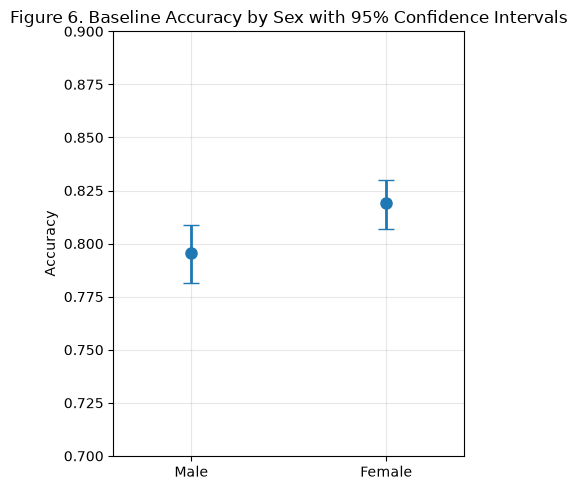

In [101]:
# =================================================
# Figure 6. Accuracy with 95% Confidence Intervals
# =================================================

plt.figure(figsize=(4.5, 5))

plt.errorbar(
    ci_results["Group"],
    ci_results["mean_acc"],
    yerr=[ci_results["mean_acc"] - ci_results["lower_ci"], ci_results["upper_ci"] - ci_results["mean_acc"]],
    fmt='o',
    markersize=8,
    capsize=6,
    elinewidth=2,
)
plt.ylabel("Accuracy")

# Set the y-axis limits
plt.xlim(-0.4, 1.4)
plt.ylim(0.70, 0.90)

plt.title("Figure 6. Baseline Accuracy by Sex with 95% Confidence Intervals")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Confidence Interval Interpretation**

Figure 6 shows the estimated accuracy for male and female customers together with 95% bootstrap confidence intervals. Female customers achieved a slightly higher estimated accuracy (81.9%) than male customers (79.6%). However, the confidence intervals overlap, indicating that the observed difference may reasonable be explained by sampling variation rather than representing a genuine difference in model performance.

Consistent with the assignment guidance, the overlapping confidence intervals mean that there is insufficient evidence to conclude that the baseline model performs differently for male and female customers. Although small differences in subgroup accuracy are present, they should be treated as unconfirmed until stronger statistical evidence is available. This illustrates the importance of considering uncertainty when evaluating fairness, rather than relying solely on point estimates.

#### **6.6 Fairness Trade-offs and the Impossibility Result**

Responsible AI requires recognising that different definitions of fairness may conflict with one another. In many real-world classification problems, it is not possible to satisfy all fairness criteria simultaneously when demographic groups have different underlying outcome rates.

In this lending case, Demographic Parity seeks to equalise the rate at which applicants are predicted to default scross demographic groups. Equalized Odds instead focuses on equalising the model's error rates by ensuring similar true positive and false positive rates for each group. Improving one of these fairness measures often causes the other to deteriorate.

The baseline model produced relatively small values for both Demographic Parity Difference (0.0218) and Equalized Odds Difference (0.0241), indicating only modest differences between male and female customers. However, even small disparities illustrate the broader Responsible AI principle that fairness is not a single measurable property. Instead, developers must decide which fairness objective is most appropriate for the lending context and justify that decision based on the potential harms associated with incorrect predictions.

#### **6.7 Fairness Mitigation**

The previous analysis showed that the baseline Logistic Regression model exhibited small differences in fairness between male and female customers. One way of addressing these differences is to apply a fairness-aware learning algorithm.

This analysis uses Fairlearn's **Exponentiated Gradient** algorithm as an in-processing mitigation technique. Unlike the baseline model, which optimises only predictive performance, Exponentiated Gradient incorporates fairness constraints during model training. The objective is to reduce differences between demographic groups while maintaining an acceptable level of predictive accuracy.

The mitigated model is compared with the baseline using the same evaluation metrics to assess the trade-off between fairness and predictive performance.

In [106]:
# =================================================
# Exponentiated Gradient (Demographic Parity)
# =================================================

eg_model = ExponentiatedGradient(
    estimator=LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    constraints=DemographicParity()
)

eg_model.fit(X_train, y_train, sensitive_features=A_train)

y_pred_eg = eg_model.predict(X_test)

In [108]:
# =================================================
# Evaluate the Mitigated Model
# =================================================

accuracy_eg = accuracy_score(y_test, y_pred_eg)

dp_eg = demographic_parity_difference(y_true=y_test, y_pred=y_pred_eg, sensitive_features=A_test)

eo_eg = equalized_odds_difference(y_true=y_test, y_pred=y_pred_eg, sensitive_features=A_test)

print(f"Accuracy                      : {accuracy_eg:.4f} ({accuracy_eg:.2%})")
print(f"Demographic Parity Difference : {dp_eg:.4f}")
print(f"Equalized Odds Difference     : {eo_eg:.4f}")

Accuracy                      : 0.8084 (80.84%)
Demographic Parity Difference : 0.0057
Equalized Odds Difference     : 0.0213


In [110]:
# =================================================
# Compare Baseline and Mitigated Model Performance
# =================================================

comparison = pd.DataFrame({
    "Model": ["Baseline Logistic Regression", "Exponentiated Gradient (Demographic Parity)"],
    "Accuracy": [accuracy, accuracy_eg],
    "Demographic Parity Difference": [dp_difference, dp_eg],
    "Equalized Odds Difference": [eo_difference, eo_eg]
})

# comparison = comparison.round(4)

comparison["Accuracy"] = comparison["Accuracy"].apply(lambda x: f"{x:.4f} ({x:.2%})")
comparison["Demographic Parity Difference"] = comparison["Demographic Parity Difference"].round(4)
comparison["Equalized Odds Difference"] = comparison["Equalized Odds Difference"].round(4)

comparison

,Model,Accuracy,Demographic Parity Difference,Equalized Odds Difference
0,Baseline Logistic Regression,0.8097 (80.97%),0.0218,0.0241
1,Exponentiated Gradient (Demographic Parity),0.8084 (80.84%),0.0057,0.0213


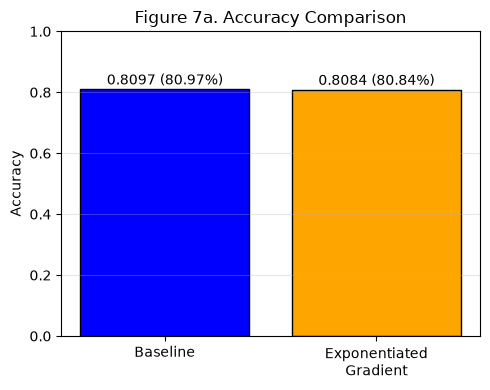

In [112]:
# =================================================
# Figure 7a. Accuracy Comparison
# =================================================

models = ["Baseline", "Exponentiated\nGradient"]
accuracy_values = [accuracy, accuracy_eg]

plt.figure(figsize=(5, 4))

bars = plt.bar(models, accuracy_values, color=['blue', 'orange'], edgecolor='black')

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.005,
        f"{height:.4f} ({height:.2%})",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.ylim(0, 1)
plt.ylabel("Accuracy")
plt.title("Figure 7a. Accuracy Comparison")
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

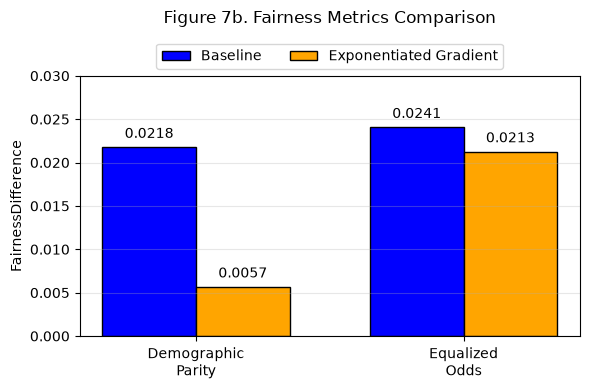

In [123]:
# =================================================
# Figure 7b. Fairness Metrics Comparison
# =================================================

metric_names = ["Demographic\nParity", "Equalized\nOdds"]
baseline_values = [dp_difference, eo_difference]
mitigated_values = [dp_eg, eo_eg]

x = np.arange(len(metric_names))
width = 0.35

plt.figure(figsize=(6, 4))

# Draw the bars and save them
bars1 =plt.bar(x - width/2, baseline_values, width, label='Baseline', color='blue', edgecolor='black')
bars2 = plt.bar(x + width/2, mitigated_values, width, label='Exponentiated Gradient', color='orange', edgecolor='black')

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width()/2,
            height + 0.0007,
            f"{height:.4f}",
            ha="center",
            va="bottom",
            fontsize=10
        )

plt.xticks(x, metric_names)
plt.ylabel("FairnessDifference")
plt.ylim(0, 0.030)
plt.title("Figure 7b. Fairness Metrics Comparison", pad=38)
plt.legend(loc='upper center', bbox_to_anchor=(0.5, 1.15), ncol=2)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


#### **6.8 Key Findings**

The baseline Logistic Regression model achieved good overall predictive performance, with an accuracy of approximately **81%**. As shown in **Figure 7a**, the Exponentiated Gradient mitigation resulted in only a very small reduction in accuracy, indicating that fairness improvements were achieved with minimal impact on the model's predictive capability. However, Responsible AI requires more than high predictive performance alone. The subgroup analysis showed small differences in model behaviour between male and female customers, while the confidence interval analysis indicated that the observed differences in subgroup accuracy should be treated with caution because the intervals overlapped.

**Figure 7b** shows that applying the Exponentiated Gradient mitigation substantially reduced the Demographic Parity Difference (from **0.0218** to **0.0057**), while producing only a negligible reduction in model accuracy. The Equalized Odds Difference also improved slightly (from **0.0241** to **0.0213**). These findings demonstrate that fairness can be improved without materially reducing predictive performance in this lending application.

Overall, the mitigated model represents a better balance between predictive performance and fairness than the baseline model. Although no automated decision system can be considered completely fair, the evidence presented in **Figures 7a and 7b** suggests that fairness-aware machine learning techniques can reduce demographic disparities while maintaining an acceptable level of predictive accuracy. These findings provide a strong basis for the broader Responsible AI considerations discussed in the following sections.

### <span style="color:orange;font-weight:bold">7. Responsible AI Risks</span>

The previous sections evaluated the dataset, baseline model and fairness mitigation from both predictive and fairness perspectives. However, responsible deployment of an AI-enabled lending system requires consideration of risks beyond model performance alone. The following analysis identifies the principal risks associated with the dataset and model, explains where each risk originates, and recommends actions that developers and deployers should take to reduce potential harm.

Table 3 summarises the principal risks identified across the AI lifecycle. Each risk is linked to evidence from the dataset or model evaluation, its likely source, and a recommended response.

In [126]:
# =================================================
# Table 3. Responsible AI Risks
# =================================================

risk_table = pd.DataFrame({
    "Risk": [
        "Potential demographic disparities",
        "Sensitive customer information",
        "Low detection of actual defaults",
        "Outcome is an incomplete proxy"
    ],
    "Category": [
        "Fairness",
        "Privacy",
        "Reliability",
        "Measurement\nValidity"
    ],
    "Evidence": [
        "DPD reduced from 0.0218 to 0.0057 after mitigation.",
        "Dataset contains demographic and financial information.",
        "Recall for Default = 24%; many defaulters are missed.",
        "Target predicts next-month default, not long-term creditworthiness."
    ],
    "Source": [
        "Historical data and model optimisation",
        "Data collection and storage",
        "Model design and class imbalance",
        "Outcome variable selection"
    ],
    "Action": [
        "Apply fairness-aware training and monitor subgroup performance.",
        "Use encryption, access controls and data minimisation.",
        "Retain human review, tune thresholds and retrain periodically.",
        "Review the prediction target and validate against longer-term outcomes."
    ]
})

(
    risk_table.style
    .set_caption("Table 3. Responsible AI Risks Identified in the Credit Default Prediction Model")
    .hide(axis="index")
    .set_properties(**{
        "text-align": "left",
        "vertical-align": "top",
        "white-space": "normal"
    })
    .set_table_styles([
        {"selector": "caption", "props": [("text-align", "left"), ("font-size", "15pt"), ("font-weight", "bold"), ("padding-bottom", "10px")]},
        {"selector": "th", "props": [("background-color", "#003366"),("text-align", "left"), ("vertical-align", "top"), ("white-space", "normal")]},
        {"selector": "td", "props": [("padding", "8px"),("text-align", "left"), ("vertical-align", "top"), ("white-space", "normal")]}
    ])
)

Risk,Category,Evidence,Source,Action
Potential demographic disparities,Fairness,DPD reduced from 0.0218 to 0.0057 after mitigation.,Historical data and model optimisation,Apply fairness-aware training and monitor subgroup performance.
Sensitive customer information,Privacy,Dataset contains demographic and financial information.,Data collection and storage,"Use encryption, access controls and data minimisation."
Low detection of actual defaults,Reliability,Recall for Default = 24%; many defaulters are missed.,Model design and class imbalance,"Retain human review, tune thresholds and retrain periodically."
Outcome is an incomplete proxy,Measurement Validity,"Target predicts next-month default, not long-term creditworthiness.",Outcome variable selection,Review the prediction target and validate against longer-term outcomes.


**7.1 Fairness Risk**

Although the fairness analysis found only small differences between male and female customers, fairness remains an ongoing concern because lending decisions directly affect access to financial services. Even relatively small disparities may become more significant when applied across large populations. The mitigation results demonstrated that fairness-aware learning substantially reduced the Demographic Parity Difference with only a negligible reduction in predictive accuracy, suggesting that fairness interventions should be considered during model development. Developers should routinely monitor fairness metrics after deployment and retrain the model if meaningful disparities emerge.

**7.2 Privacy Risk**

The dataset contains sensitive demographic and financial information, including age, sex, education level, marital status, repayment history and monthly financial records. Although the dataset used for this assignment is de-identified, these attributes remain sensitive and require appropriate protection because combinations of demographic and financial information may increase the risk of re-identification. Organisations deploying this system should implement strong access controls, encryption, audit logging and data minimisation practices to ensure that personal information is used only for legitimate lending purposes.

**7.3 Reliability Risk**

The baseline model achieved an overall accuracy of approximately 81%; however, the classification report showed that the recall for customers who subsequently defaulted was only 24%. This means that many customers who lated defaulted were incorrectly predicted as low risk. In a lending context, these false negatives may expose the lender to financial losses through inappropriate credit approvals. For this reason, model predictions should support rather than replace human decision-making, particularly for applications close to the lender's approval threshold. Periodic retraining and threshold adjustment should also be considered as customer behaviour changes over time.

**7.4 Measurement Validity Risk**

The outcome variable records whether a customer defaulted on their next payment, which serves as a practical proxy for credit risk but does not directly measure long-term creditworthiness or financial responsibility. Customers may miss a single payment for reasons unrelated to their overall financial behaviour, while others who make their next payment may still experience financial difficulties in the future. Consequently, decisions based solely on this outcome variable may not fully reflect an applicant's true creditworthiness. Developers should periodically review whether the prediction target remains appropriate and consider incorporating additional indicators of longer-term financial performance.

**7.5 Summary**

The analysis identified four principal Responsible AI risks associated with the proposed lending system: demographic fairness, privacy, reliability and measurement validity. Importantly, each risk originates from a different stage of the AI lifecycle, including the design of the dataset, the choice of prediction target, the model development process and the operational deployment of the system. Addressing these risks therefore requires both technical measures, such as fairness-aware training and secure data management, and organisational measures, including human oversight, ongoing monitoring and periodic model review.

### <span style="color:orange;font-weight:bold">8. Foundation Model Alternative</span>

### <span style="color:orange;font-weight:bold">9. Recommendation</span>

### <span style="color:orange;font-weight:bold">10. References</span>

### <span style="color:orange;font-weight:bold">11. Appendix</span>